In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import itertools
from tqdm import tqdm

# ── Reproducibility ────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

# ── Config ─────────────────────────────────────────────────────
TRAIN_IMG_DIR  = r"D:\where_stream\ActualSplittedDataset\train\images"
TRAIN_MASK_DIR = r"D:\where_stream\ActualSplittedDataset\train\masks"
VAL_IMG_DIR    = r"D:\where_stream\ActualSplittedDataset\val\images"
VAL_MASK_DIR   = r"D:\where_stream\ActualSplittedDataset\val\masks"
TEST_IMG_DIR   = r"D:\where_stream\ActualSplittedDataset\test\images"
TEST_MASK_DIR  = r"D:\where_stream\ActualSplittedDataset\test\masks"

NUM_CLASSES = 5
IMAGE_SIZE  = 224
BATCH_SIZE  = 8
LR          = 1e-4
EPOCHS      = 100
PATIENCE    = 10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "background",
    "femoral_condyle",
    "lateral_js",
    "medial_js",
    "tibial_plateau"
]

for exp in ["exp1","exp2","exp3","exp4","exp5","final"]:
    os.makedirs(f"seresunet_results/{exp}", exist_ok=True)

ALL_RESULTS   = {}
ALL_HISTORIES = {}

print(f"Device  : {DEVICE}")
print(f"Classes : {CLASS_NAMES}")

Device  : cpu
Classes : ['background', 'femoral_condyle', 'lateral_js', 'medial_js', 'tibial_plateau']


In [3]:
class KneeDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.images    = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image    = cv2.imread(
            os.path.join(self.image_dir, img_name),
            cv2.IMREAD_GRAYSCALE)
        mask     = cv2.imread(
            os.path.join(self.mask_dir, img_name),
            cv2.IMREAD_GRAYSCALE)
        image    = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        mask     = cv2.resize(
            mask, (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        image = image / 255.0
        image = np.expand_dims(image, axis=0)
        return (torch.tensor(image, dtype=torch.float32),
                torch.tensor(mask,  dtype=torch.long))


transform_baseline = None

transform_augmented = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2, p=0.3),
    A.GaussianBlur(blur_limit=3, p=0.2)
])


def get_loaders(train_transform=None, batch_size=BATCH_SIZE):
    train_ds = KneeDataset(
        TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_transform)
    val_ds   = KneeDataset(VAL_IMG_DIR,  VAL_MASK_DIR)
    test_ds  = KneeDataset(TEST_IMG_DIR, TEST_MASK_DIR)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(
        val_ds,   batch_size=batch_size,
        shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(
        test_ds,  batch_size=batch_size,
        shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_loaders()
print(f"Train : {len(train_loader.dataset)} images")
print(f"Val   : {len(val_loader.dataset)} images")
print(f"Test  : {len(test_loader.dataset)} images")

sample = cv2.imread(
    os.path.join(TRAIN_MASK_DIR,
                 os.listdir(TRAIN_MASK_DIR)[0]),
    cv2.IMREAD_GRAYSCALE)
print(f"\nMask pixel values : {np.unique(sample)}")
print(f"Expected          : [0 1 2 3 4]")

Train : 84 images
Val   : 18 images
Test  : 18 images

Mask pixel values : [0 1 2 3 4]
Expected          : [0 1 2 3 4]


In [4]:
# ══════════════════════════════════════════════════════════════
#  SHARED BUILDING BLOCKS
#  These are used in different combinations across experiments
#  to show WHAT each contribution adds
# ══════════════════════════════════════════════════════════════

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.block(x)


class PlainDoubleConv(nn.Module):
    """Standard U-Net decoder conv — no residual connection."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.block(x)


class ResidualDoubleConv(nn.Module):
    """Decoder conv WITH residual shortcut — ★3."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1    = ConvBNReLU(in_ch, out_ch)
        self.conv2    = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch))
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.relu(
            self.conv2(self.conv1(x)) + self.shortcut(x))


class SqueezeExcitation(nn.Module):
    """Channel attention — ★4."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid())
    def forward(self, x):
        return x * self.se(x).view(
            x.shape[0], x.shape[1], 1, 1)


print("Building blocks loaded.")

Building blocks loaded.


In [5]:
# ══════════════════════════════════════════════════════════════
#  ALL MODEL VARIANTS FOR EXPERIMENTS
#
#  Exp 1: BaselineUNet     — plain encoder-decoder, ResNet34,
#                            no pretrained, plain conv, no SE
#  Exp 2: PretrainedUNet   — ResNet34 pretrained (adds ★2 partial)
#  Exp 3: InputProjUNet    — adds ★1 input projection
#  Exp 4: ResDecUNet       — adds ★3 residual decoder conv
#  Exp 5: SEResUNet        — adds ★4 SE attention + ★5 deep sup
#          = FINAL PROPOSED MODEL
#
#  Each experiment adds ONE contribution to the previous best.
#  This directly answers "how did you arrive at SE-ResUNet?"
# ══════════════════════════════════════════════════════════════


# ── EXPERIMENT 1 — Baseline U-Net ─────────────────────────────
# Plain encoder-decoder, ResNet34 random init, plain double conv
# No pretrained weights, no input projection, no SE, no aux head
# This is the simplest possible U-Net baseline

class BaselineUNet(nn.Module):
    """
    Experiment 1 — Baseline U-Net
    ──────────────────────────────
    Encoder : ResNet34 randomly initialised
    Decoder : Plain double conv (standard U-Net)
    Input   : direct grayscale (1ch)
    SE      : No
    Aux head: No
    Purpose : Performance floor — shows what standard U-Net
              achieves on knee X-ray segmentation
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # ResNet34 with NO pretrained weights
        resnet        = models.resnet34(weights=None)
        # Modify first conv to accept 1-channel input directly
        resnet.conv1  = nn.Conv2d(
            1, 64, 7, stride=2, padding=3, bias=False)

        self.enc0     = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu)
        self.pool     = resnet.maxpool
        self.enc1     = resnet.layer1   # 64ch  56×56
        self.enc2     = resnet.layer2   # 128ch 28×28
        self.enc3     = resnet.layer3   # 256ch 14×14
        self.enc4     = resnet.layer4   # 512ch  7×7

        self.bottleneck = PlainDoubleConv(512, 512)

        # Plain decoder — standard U-Net style
        self.dec4_up  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4_cv  = PlainDoubleConv(256+256, 256)

        self.dec3_up  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3_cv  = PlainDoubleConv(128+128, 128)

        self.dec2_up  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2_cv  = PlainDoubleConv(64+64, 64)

        self.dec1_up  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1_cv  = PlainDoubleConv(32+64, 32)

        self.dec0_up  = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec0_cv  = PlainDoubleConv(16+64, 16)

        self.head     = nn.Conv2d(16, num_classes, 1)

    def _dec(self, x, skip, up, cv):
        x = up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear',
                               align_corners=False)
        return cv(torch.cat([x, skip], dim=1))

    def forward(self, x):
        e0  = self.enc0(x)
        ep  = self.pool(e0)
        e1  = self.enc1(ep)
        e2  = self.enc2(e1)
        e3  = self.enc3(e2)
        e4  = self.enc4(e3)
        b   = self.bottleneck(e4)
        d4  = self._dec(b,  e3, self.dec4_up, self.dec4_cv)
        d3  = self._dec(d4, e2, self.dec3_up, self.dec3_cv)
        d2  = self._dec(d3, e1, self.dec2_up, self.dec2_cv)
        d1  = self._dec(d2, ep, self.dec1_up, self.dec1_cv)
        d0  = self._dec(d1, e0, self.dec0_up, self.dec0_cv)
        out = self.head(d0)
        if out.shape[2:] != (IMAGE_SIZE, IMAGE_SIZE):
            out = F.interpolate(
                out, size=(IMAGE_SIZE, IMAGE_SIZE),
                mode='bilinear', align_corners=False)
        return out, None   # None = no aux output

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── EXPERIMENT 2 — Pretrained Encoder ─────────────────────────
# Adds ImageNet pretrained ResNet34 weights
# Everything else identical to Exp1
# Tests: does pretraining help on 84-image dataset?

class PretrainedUNet(nn.Module):
    """
    Experiment 2 — Pretrained Encoder
    ───────────────────────────────────
    Adds  : ResNet34 pretrained ImageNet weights
    Change: direct 1ch input handled by weight averaging
    Same  : plain double conv decoder, no SE, no aux
    Purpose: Test whether pretrained features help
             when training set is only 84 images
    """
    def __init__(self, num_classes=5):
        super().__init__()
        resnet = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1)

        # Average RGB pretrained weights to single channel
        # This preserves pretrained knowledge better than
        # randomly reinitialising the first conv
        orig_weight      = resnet.conv1.weight.data
        new_weight       = orig_weight.mean(dim=1, keepdim=True)
        resnet.conv1     = nn.Conv2d(
            1, 64, 7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data = new_weight

        self.enc0        = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu)
        self.pool        = resnet.maxpool
        self.enc1        = resnet.layer1
        self.enc2        = resnet.layer2
        self.enc3        = resnet.layer3
        self.enc4        = resnet.layer4

        self.bottleneck  = PlainDoubleConv(512, 512)

        self.dec4_up     = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4_cv     = PlainDoubleConv(256+256, 256)
        self.dec3_up     = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3_cv     = PlainDoubleConv(128+128, 128)
        self.dec2_up     = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2_cv     = PlainDoubleConv(64+64, 64)
        self.dec1_up     = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1_cv     = PlainDoubleConv(32+64, 32)
        self.dec0_up     = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec0_cv     = PlainDoubleConv(16+64, 16)
        self.head        = nn.Conv2d(16, num_classes, 1)

    def _dec(self, x, skip, up, cv):
        x = up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear', align_corners=False)
        return cv(torch.cat([x, skip], dim=1))

    def forward(self, x):
        e0  = self.enc0(x)
        ep  = self.pool(e0)
        e1  = self.enc1(ep)
        e2  = self.enc2(e1)
        e3  = self.enc3(e2)
        e4  = self.enc4(e3)
        b   = self.bottleneck(e4)
        d4  = self._dec(b,  e3, self.dec4_up, self.dec4_cv)
        d3  = self._dec(d4, e2, self.dec3_up, self.dec3_cv)
        d2  = self._dec(d3, e1, self.dec2_up, self.dec2_cv)
        d1  = self._dec(d2, ep, self.dec1_up, self.dec1_cv)
        d0  = self._dec(d1, e0, self.dec0_up, self.dec0_cv)
        out = self.head(d0)
        if out.shape[2:] != (IMAGE_SIZE, IMAGE_SIZE):
            out = F.interpolate(out, size=(IMAGE_SIZE, IMAGE_SIZE),
                                 mode='bilinear', align_corners=False)
        return out, None

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── EXPERIMENT 3 — Input Projection Layer ★1 ──────────────────
# Adds learned 1→3 channel projection before encoder
# Tests: does learned projection outperform weight averaging?
# Uses ResNet50 encoder (confirmed best from encoder study)

class InputProjUNet(nn.Module):
    """
    Experiment 3 — Learned Input Projection ★1
    ────────────────────────────────────────────
    Adds  : Conv1×1 (1→3ch) + BN + ReLU before encoder
    Encoder: ResNet50 pretrained (stronger than ResNet34)
    Same  : plain double conv decoder, no SE, no aux
    Purpose: Test learned projection vs weight averaging
             Also upgrades encoder to ResNet50
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # ★1 learned input projection
        self.input_proj = nn.Sequential(
            nn.Conv2d(1, 3, 1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True))

        resnet     = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.enc0  = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu)
        self.pool  = resnet.maxpool
        self.enc1  = resnet.layer1   # 256ch 56×56
        self.enc2  = resnet.layer2   # 512ch 28×28
        self.enc3  = resnet.layer3   # 1024ch 14×14
        self.enc4  = resnet.layer4   # 2048ch 7×7

        self.bottleneck = PlainDoubleConv(2048, 1024)

        self.dec4_up = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4_cv = PlainDoubleConv(512+1024, 512)
        self.dec3_up = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.dec3_cv = PlainDoubleConv(256+512, 256)
        self.dec2_up = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.dec2_cv = PlainDoubleConv(128+256, 128)
        self.dec1_up = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.dec1_cv = PlainDoubleConv(64+64,   64)
        self.dec0_up = nn.ConvTranspose2d(64,    32, 2, stride=2)
        self.dec0_cv = PlainDoubleConv(32+64,    32)
        self.head    = nn.Conv2d(32, num_classes, 1)

    def _dec(self, x, skip, up, cv):
        x = up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear', align_corners=False)
        return cv(torch.cat([x, skip], dim=1))

    def forward(self, x):
        x   = self.input_proj(x)        # ★1
        e0  = self.enc0(x)
        ep  = self.pool(e0)
        e1  = self.enc1(ep)
        e2  = self.enc2(e1)
        e3  = self.enc3(e2)
        e4  = self.enc4(e3)
        b   = self.bottleneck(e4)
        d4  = self._dec(b,  e3, self.dec4_up, self.dec4_cv)
        d3  = self._dec(d4, e2, self.dec3_up, self.dec3_cv)
        d2  = self._dec(d3, e1, self.dec2_up, self.dec2_cv)
        d1  = self._dec(d2, ep, self.dec1_up, self.dec1_cv)
        d0  = self._dec(d1, e0, self.dec0_up, self.dec0_cv)
        out = self.head(d0)
        if out.shape[2:] != (IMAGE_SIZE, IMAGE_SIZE):
            out = F.interpolate(out, size=(IMAGE_SIZE, IMAGE_SIZE),
                                 mode='bilinear', align_corners=False)
        return out, None

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── EXPERIMENT 4 — Residual Decoder ★3 ────────────────────────
# Replaces plain double conv with ResidualDoubleConv in decoder
# Tests: do residual shortcuts improve small dataset training?

class ResDecUNet(nn.Module):
    """
    Experiment 4 — Residual Decoder Conv ★3
    ─────────────────────────────────────────
    Adds  : ResidualDoubleConv in all decoder blocks
    Same  : ★1 input proj, ResNet50 pretrained, no SE, no aux
    Purpose: Test whether residual shortcuts improve gradient
             flow on 84-image training set
    """
    def __init__(self, num_classes=5):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv2d(1, 3, 1, bias=False),
            nn.BatchNorm2d(3), nn.ReLU(inplace=True))

        resnet     = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.enc0  = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu)
        self.pool  = resnet.maxpool
        self.enc1  = resnet.layer1
        self.enc2  = resnet.layer2
        self.enc3  = resnet.layer3
        self.enc4  = resnet.layer4

        self.bottleneck = ResidualDoubleConv(2048, 1024)

        # ★3 residual double conv in decoder
        self.dec4_up = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4_cv = ResidualDoubleConv(512+1024, 512)
        self.dec3_up = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.dec3_cv = ResidualDoubleConv(256+512, 256)
        self.dec2_up = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.dec2_cv = ResidualDoubleConv(128+256, 128)
        self.dec1_up = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.dec1_cv = ResidualDoubleConv(64+64,   64)
        self.dec0_up = nn.ConvTranspose2d(64,    32, 2, stride=2)
        self.dec0_cv = ResidualDoubleConv(32+64,   32)
        self.head    = nn.Conv2d(32, num_classes, 1)

    def _dec(self, x, skip, up, cv):
        x = up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear', align_corners=False)
        return cv(torch.cat([x, skip], dim=1))

    def forward(self, x):
        x   = self.input_proj(x)
        e0  = self.enc0(x)
        ep  = self.pool(e0)
        e1  = self.enc1(ep)
        e2  = self.enc2(e1)
        e3  = self.enc3(e2)
        e4  = self.enc4(e3)
        b   = self.bottleneck(e4)
        d4  = self._dec(b,  e3, self.dec4_up, self.dec4_cv)
        d3  = self._dec(d4, e2, self.dec3_up, self.dec3_cv)
        d2  = self._dec(d3, e1, self.dec2_up, self.dec2_cv)
        d1  = self._dec(d2, ep, self.dec1_up, self.dec1_cv)
        d0  = self._dec(d1, e0, self.dec0_up, self.dec0_cv)
        out = self.head(d0)
        if out.shape[2:] != (IMAGE_SIZE, IMAGE_SIZE):
            out = F.interpolate(out, size=(IMAGE_SIZE, IMAGE_SIZE),
                                 mode='bilinear', align_corners=False)
        return out, None

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── EXPERIMENT 5 — Full SE-ResUNet ★1★2★3★4★5 ─────────────────
# Adds SE channel attention + deep supervision aux head
# This is the FINAL PROPOSED MODEL

class SEResUNet(nn.Module):
    """
    Experiment 5 — Full SE-ResUNet (Proposed)
    ───────────────────────────────────────────
    Adds  : ★4 SE channel attention after each decoder block
            ★5 Deep supervision auxiliary head at dec2
    All   : ★1 input proj + ★2 ResNet50 pretrained
            + ★3 residual decoder conv
    Purpose: Complete proposed architecture
    """
    def __init__(self, num_classes=5):
        super().__init__()
        self.num_classes = num_classes

        # ★1
        self.input_proj = nn.Sequential(
            nn.Conv2d(1, 3, 1, bias=False),
            nn.BatchNorm2d(3), nn.ReLU(inplace=True))

        # ★2
        resnet     = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.enc0  = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu)
        self.pool  = resnet.maxpool
        self.enc1  = resnet.layer1
        self.enc2  = resnet.layer2
        self.enc3  = resnet.layer3
        self.enc4  = resnet.layer4

        self.bottleneck = ResidualDoubleConv(2048, 1024)

        # ★3 + ★4 in each decoder block
        self.dec4_up = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4_cv = ResidualDoubleConv(512+1024, 512)
        self.dec4_se = SqueezeExcitation(512)

        self.dec3_up = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.dec3_cv = ResidualDoubleConv(256+512, 256)
        self.dec3_se = SqueezeExcitation(256)

        self.dec2_up = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.dec2_cv = ResidualDoubleConv(128+256, 128)
        self.dec2_se = SqueezeExcitation(128)

        # ★5 auxiliary head
        self.aux_head = nn.Conv2d(128, num_classes, 1)

        self.dec1_up = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.dec1_cv = ResidualDoubleConv(64+64,  64)
        self.dec1_se = SqueezeExcitation(64)

        self.dec0_up = nn.ConvTranspose2d(64,    32, 2, stride=2)
        self.dec0_cv = ResidualDoubleConv(32+64,  32)
        self.dec0_se = SqueezeExcitation(32)

        self.head = nn.Conv2d(32, num_classes, 1)

    def _dec(self, x, skip, up, cv, se):
        x = up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear', align_corners=False)
        return se(cv(torch.cat([x, skip], dim=1)))

    def forward(self, x):
        x   = self.input_proj(x)
        e0  = self.enc0(x)
        ep  = self.pool(e0)
        e1  = self.enc1(ep)
        e2  = self.enc2(e1)
        e3  = self.enc3(e2)
        e4  = self.enc4(e3)
        b   = self.bottleneck(e4)
        d4  = self._dec(b,  e3, self.dec4_up,
                        self.dec4_cv, self.dec4_se)
        d3  = self._dec(d4, e2, self.dec3_up,
                        self.dec3_cv, self.dec3_se)
        d2  = self._dec(d3, e1, self.dec2_up,
                        self.dec2_cv, self.dec2_se)
        aux = F.interpolate(
            self.aux_head(d2),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode='bilinear', align_corners=False)
        d1  = self._dec(d2, ep, self.dec1_up,
                        self.dec1_cv, self.dec1_se)
        d0  = self._dec(d1, e0, self.dec0_up,
                        self.dec0_cv, self.dec0_se)
        out = self.head(d0)
        if out.shape[2:] != (IMAGE_SIZE, IMAGE_SIZE):
            out = F.interpolate(out, size=(IMAGE_SIZE, IMAGE_SIZE),
                                 mode='bilinear', align_corners=False)
        return out, aux

    def count_params(self):
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ── Parameter summary ──────────────────────────────────────────
print("Model parameter counts:")
print(f"  Exp1 BaselineUNet  : {BaselineUNet().count_params():,}")
print(f"  Exp2 PretrainedUNet: {PretrainedUNet().count_params():,}")
print(f"  Exp3 InputProjUNet : {InputProjUNet().count_params():,}")
print(f"  Exp4 ResDecUNet    : {ResDecUNet().count_params():,}")
print(f"  Exp5 SEResUNet     : {SEResUNet().count_params():,}")

Model parameter counts:
  Exp1 BaselineUNet  : 29,073,093
  Exp2 PretrainedUNet: 29,073,093
  Exp3 InputProjUNet : 67,156,046
  Exp4 ResDecUNet    : 70,300,686
  Exp5 SEResUNet     : 70,389,743


In [6]:
def dice_loss(pred, target, smooth=1.0):
    pred       = torch.softmax(pred, dim=1)
    target_oh  = F.one_hot(target, NUM_CLASSES)
    target_oh  = target_oh.permute(0,3,1,2).float()
    inter      = (pred * target_oh).sum(dim=(2,3))
    union      = pred.sum(dim=(2,3)) + target_oh.sum(dim=(2,3))
    return 1 - ((2*inter+smooth) / (union+smooth)).mean()


def combined_loss(main_pred, aux_pred, target,
                   aux_weight=0.4):
    main = dice_loss(main_pred, target)
    if aux_pred is None:
        return main
    return main + aux_weight * dice_loss(aux_pred, target)


def dice_per_class(pred, target, smooth=1.0):
    pred_cls = torch.argmax(pred, dim=1)
    scores   = []
    for cls in range(NUM_CLASSES):
        p     = (pred_cls == cls).float()
        t     = (target   == cls).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum()
        scores.append(
            torch.tensor(1.0) if union == 0
            else (2*inter+smooth)/(union+smooth))
    return scores


def iou_per_class(pred, target, smooth=1.0):
    pred_cls = torch.argmax(pred, dim=1)
    scores   = []
    for cls in range(NUM_CLASSES):
        p     = (pred_cls == cls).float()
        t     = (target   == cls).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append(
            torch.tensor(1.0) if union == 0
            else (inter+smooth)/(union+smooth))
    return scores


def pixel_accuracy(pred, target):
    return (torch.argmax(pred, dim=1) == target
            ).float().mean().item()


print("Loss functions and metrics loaded.")

Loss functions and metrics loaded.


In [7]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE):
        self.patience  = patience
        self.best_loss = float("inf")
        self.counter   = 0
    def step(self, val_loss):
        if val_loss < self.best_loss - 1e-4:
            self.best_loss = val_loss
            self.counter   = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def run_training(model, train_loader, val_loader,
                 optimizer, scheduler, save_path,
                 exp_name, epochs=EPOCHS):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    stopper        = EarlyStopping()
    best_val_loss  = float("inf")
    best_mean_dice = 0.0
    history        = {
        "train_loss": [], "val_loss": [],
        "mean_dice":  [], "dice_per_cls": []
    }

    print(f"\n{'='*65}")
    print(f"  {exp_name}")
    print(f"{'='*65}")
    print(f"  {'Ep':>4} | {'TrLoss':>8} | {'VlLoss':>8} | "
          f"{'MeanDice':>9} | {'MedJS':>7}")
    print(f"  {'-'*55}")

    for epoch in range(epochs):
        # Train
        model.train()
        tr_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            main_pred, aux_pred = model(images)
            loss = combined_loss(main_pred, aux_pred, masks)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        # Validate
        model.eval()
        vl_loss    = 0.0
        dice_total = torch.zeros(NUM_CLASSES)
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                main_pred, aux_pred = model(images)
                loss = combined_loss(main_pred, aux_pred, masks)
                vl_loss    += loss.item()
                dice_total += torch.tensor(
                    dice_per_class(main_pred, masks))
        vl_loss   /= len(val_loader)
        dice_avg   = dice_total / len(val_loader)
        mean_dice  = dice_avg[1:].mean().item()
        medial_js  = dice_avg[3].item()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["mean_dice"].append(mean_dice)
        history["dice_per_cls"].append(dice_avg.tolist())

        print(f"  {epoch+1:>4} | {tr_loss:>8.4f} | "
              f"{vl_loss:>8.4f} | {mean_dice:>9.4f} | "
              f"{medial_js:>7.4f}")

        scheduler.step(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss  = vl_loss
            best_mean_dice = mean_dice
            torch.save(model.state_dict(), save_path)

        if stopper.step(vl_loss):
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    print(f"\n  Best Mean Dice : {best_mean_dice:.4f}")
    return history


def plot_learning_curves(history, exp_name, save_dir):
    epochs = range(1, len(history["train_loss"])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Learning Curves — {exp_name}",
                 fontsize=13, fontweight="bold")
    axes[0].plot(epochs, history["train_loss"],
                 label="Train", color="steelblue", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],
                 label="Val",   color="tomato",    linewidth=2)
    axes[0].set_title("Dice Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["mean_dice"],
                 color="seagreen", linewidth=2)
    axes[1].set_title("Mean Dice (excl. background)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, f"{exp_name}_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def full_evaluate(model, test_loader, exp_name, save_dir):
    model.eval()
    dice_total = torch.zeros(NUM_CLASSES)
    iou_total  = torch.zeros(NUM_CLASSES)
    pix_acc    = 0.0

    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            main_pred, _  = model(images)
            dice_total   += torch.tensor(
                dice_per_class(main_pred, masks))
            iou_total    += torch.tensor(
                iou_per_class(main_pred, masks))
            pix_acc      += pixel_accuracy(main_pred, masks)

    n               = len(test_loader)
    dice_avg        = dice_total / n
    iou_avg         = iou_total  / n
    pix_acc        /= n
    mean_dice_no_bg = dice_avg[1:].mean().item()
    mean_iou_no_bg  = iou_avg[1:].mean().item()

    print(f"\n{'─'*55}")
    print(f"  RESULTS: {exp_name}")
    print(f"{'─'*55}")
    print(f"  {'Class':<18} {'Dice':>8} {'IoU':>8}")
    print(f"  {'-'*36}")
    for i, cls in enumerate(CLASS_NAMES):
        mark = " ← key" if cls == "medial_js" else ""
        print(f"  {cls:<18} {dice_avg[i].item():>8.4f} "
              f"{iou_avg[i].item():>8.4f}{mark}")
    print(f"  {'-'*36}")
    print(f"  {'Mean (no bg)':<18} {mean_dice_no_bg:>8.4f} "
          f"{mean_iou_no_bg:>8.4f}")
    print(f"  {'Pixel Accuracy':<18} {pix_acc:>8.4f}")

    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(
            save_dir, f"{exp_name}_metrics.txt"), "w") as f:
        f.write(f"RESULTS: {exp_name}\n{'='*50}\n")
        for i, cls in enumerate(CLASS_NAMES):
            f.write(f"{cls:<18} Dice:{dice_avg[i].item():.4f} "
                    f"IoU:{iou_avg[i].item():.4f}\n")
        f.write(f"\nMean Dice (no bg): {mean_dice_no_bg:.4f}\n")
        f.write(f"Mean IoU  (no bg): {mean_iou_no_bg:.4f}\n")
        f.write(f"Pixel Accuracy   : {pix_acc:.4f}\n")

    results = {
        "dice":            dice_avg.tolist(),
        "iou":             iou_avg.tolist(),
        "mean_dice_no_bg": mean_dice_no_bg,
        "mean_iou_no_bg":  mean_iou_no_bg,
        "pix_acc":         pix_acc
    }
    ALL_RESULTS[exp_name] = results
    return results


def plot_comparison(metric="mean_dice_no_bg",
                    save_dir="seresunet_results/final"):
    if not ALL_RESULTS: return
    os.makedirs(save_dir, exist_ok=True)
    names  = list(ALL_RESULTS.keys())
    values = [ALL_RESULTS[n][metric] for n in names]
    colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
    fig, ax = plt.subplots(
        figsize=(max(10, len(names)*2), 6))
    bars = ax.bar(names, values, color=colors,
                  width=0.5, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
    ax.set_title(
        f"SE-ResUNet Experiments — "
        f"{metric.replace('_',' ').title()}",
        fontsize=13, fontweight="bold")
    ax.set_ylabel(metric.replace("_"," ").title())
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir, f"comparison_{metric}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


print("Training and evaluation utilities loaded.")

Training and evaluation utilities loaded.


  Exp1_BaselineUNet
  ResNet34 random init | plain conv | no pretrain
  Purpose: performance floor

  Exp1_BaselineUNet
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------
     1 |   0.8311 |   0.8416 |    0.1205 |  0.0003
     2 |   0.8146 |   0.8388 |    0.1220 |  0.0003
     3 |   0.7934 |   0.8232 |    0.3274 |  0.0004
     4 |   0.7720 |   0.7797 |    0.3813 |  0.0081
     5 |   0.7509 |   0.7342 |    0.4381 |  0.0198
     6 |   0.7331 |   0.7169 |    0.4842 |  0.0732
     7 |   0.7166 |   0.6995 |    0.5059 |  0.1262
     8 |   0.7018 |   0.6790 |    0.5250 |  0.1855
     9 |   0.6890 |   0.6603 |    0.5475 |  0.3191
    10 |   0.6783 |   0.6636 |    0.5484 |  0.3517
    11 |   0.6681 |   0.6598 |    0.5456 |  0.3666
    12 |   0.6593 |   0.6625 |    0.5375 |  0.3607
    13 |   0.6520 |   0.6495 |    0.5604 |  0.4455
    14 |   0.6482 |   0.6478 |    0.5615 |  0.4566
    15 |   0.6423 |   0.6470 |    0.5644 |  0.4714
    16

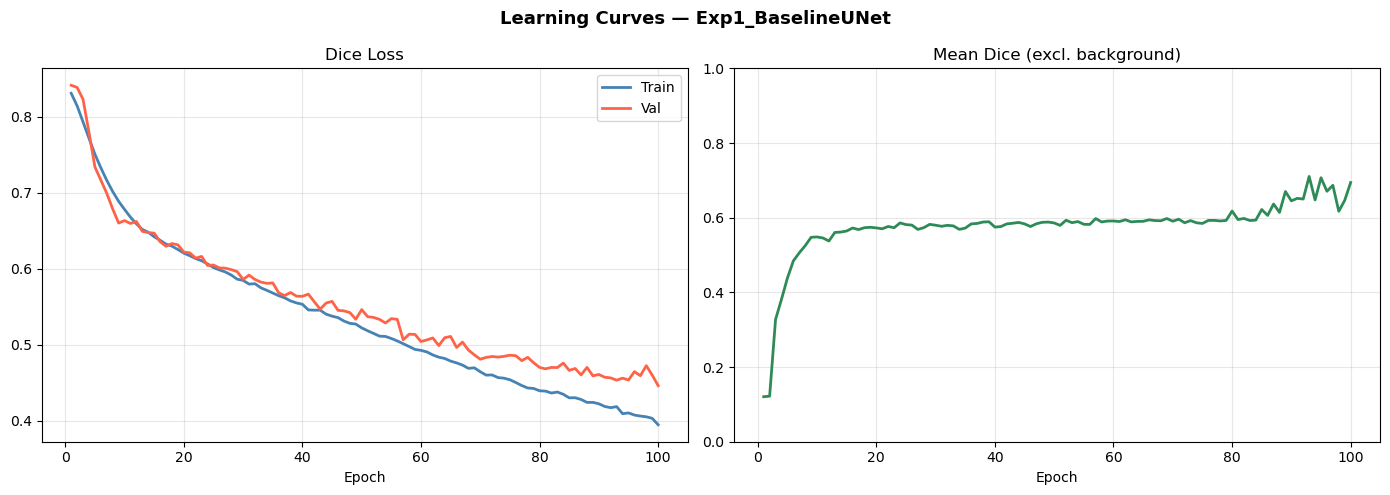

  Saved: seresunet_results/exp1\Exp1_BaselineUNet_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp1_BaselineUNet
───────────────────────────────────────────────────────
  Class                  Dice      IoU
  ------------------------------------
  background           0.8855   0.7952
  femoral_condyle      0.9102   0.8353
  lateral_js           0.3049   0.1859
  medial_js            0.5148   0.3486 ← key
  tibial_plateau       0.9243   0.8598
  ------------------------------------
  Mean (no bg)         0.6636   0.5574
  Pixel Accuracy       0.8813

  Exp1 complete — this is your floor
  Mean Dice (no bg) : 0.6636
  Medial JS Dice    : 0.5148


In [11]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 1 — BASELINE U-NET
#  ResNet34 random init | plain double conv | direct 1ch input
#  No pretrained weights | No SE | No aux head
#  Purpose: Establish performance floor
# ══════════════════════════════════════════════════════════════

EXP1_NAME = "Exp1_BaselineUNet"
EXP1_DIR  = "seresunet_results/exp1"

print("="*65)
print(f"  {EXP1_NAME}")
print("  ResNet34 random init | plain conv | no pretrain")
print("  Purpose: performance floor")
print("="*65)

train_loader, val_loader, test_loader = get_loaders(
    train_transform=transform_augmented,
    batch_size=BATCH_SIZE)

model_e1  = BaselineUNet(num_classes=5).to(DEVICE)
opt_e1    = optim.Adam(model_e1.parameters(), lr=LR)
sch_e1    = optim.lr_scheduler.ReduceLROnPlateau(
    opt_e1, mode='min', patience=5, factor=0.5)

history_e1 = run_training(
    model_e1, train_loader, val_loader,
    opt_e1, sch_e1,
    save_path=f"{EXP1_DIR}/{EXP1_NAME}_best.pth",
    exp_name=EXP1_NAME)

model_e1.load_state_dict(
    torch.load(f"{EXP1_DIR}/{EXP1_NAME}_best.pth",
               map_location=DEVICE))
plot_learning_curves(history_e1, EXP1_NAME, EXP1_DIR)
results_e1 = full_evaluate(
    model_e1, test_loader, EXP1_NAME, EXP1_DIR)
ALL_HISTORIES[EXP1_NAME] = history_e1

print(f"\n  Exp1 complete — this is your floor")
print(f"  Mean Dice (no bg) : {results_e1['mean_dice_no_bg']:.4f}")
print(f"  Medial JS Dice    : {results_e1['dice'][3]:.4f}")


  Exp2_PretrainedEncoder
  Adds: ResNet34 pretrained ImageNet weights
  Same: plain conv decoder, no SE, no aux

  Exp2_PretrainedEncoder
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------
     1 |   0.8310 |   0.8367 |    0.1028 |  0.0003
     2 |   0.7922 |   0.8364 |    0.1028 |  0.0003
     3 |   0.7599 |   0.8200 |    0.1771 |  0.0003
     4 |   0.7379 |   0.7656 |    0.4273 |  0.0003
     5 |   0.7144 |   0.7195 |    0.4390 |  0.0012
     6 |   0.6943 |   0.6903 |    0.4259 |  0.0005
     7 |   0.6798 |   0.6760 |    0.4420 |  0.0003
     8 |   0.6681 |   0.6614 |    0.4325 |  0.0003
     9 |   0.6590 |   0.6488 |    0.4374 |  0.0003
    10 |   0.6526 |   0.6495 |    0.4552 |  0.0003
    11 |   0.6461 |   0.6377 |    0.4428 |  0.0003
    12 |   0.6407 |   0.6323 |    0.4864 |  0.0003
    13 |   0.6359 |   0.6239 |    0.4720 |  0.0003
    14 |   0.6291 |   0.6233 |    0.4505 |  0.0003
    15 |   0.6250 |   0.6220 |    0.46

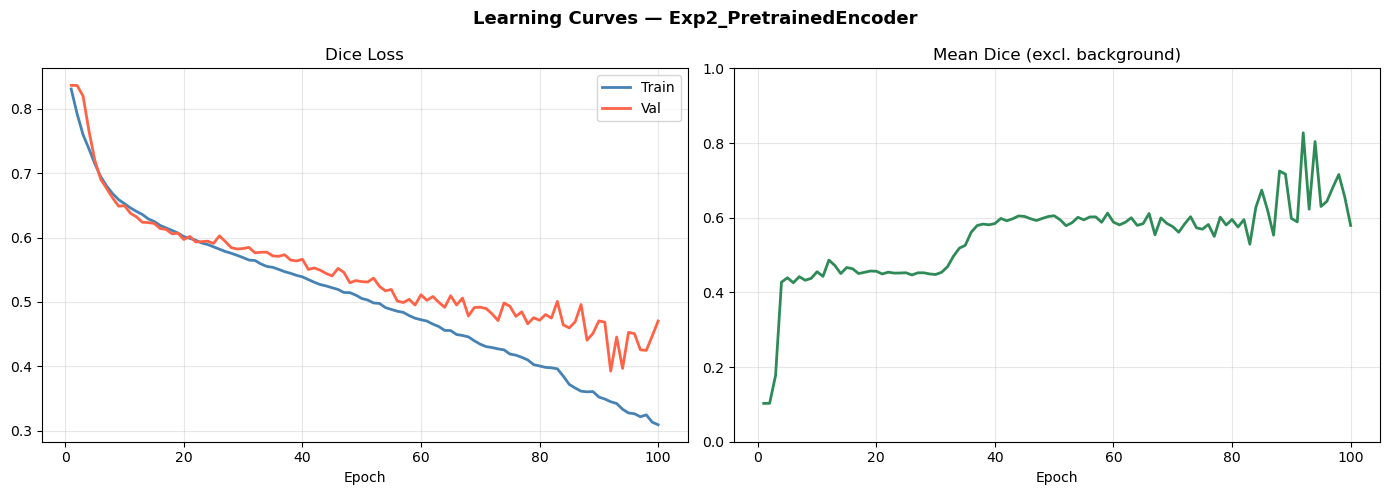

  Saved: seresunet_results/exp2\Exp2_PretrainedEncoder_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp2_PretrainedEncoder
───────────────────────────────────────────────────────
  Class                  Dice      IoU
  ------------------------------------
  background           0.9135   0.8417
  femoral_condyle      0.9180   0.8485
  lateral_js           0.7096   0.5617
  medial_js            0.6504   0.4880 ← key
  tibial_plateau       0.9446   0.8955
  ------------------------------------
  Mean (no bg)         0.8057   0.6985
  Pixel Accuracy       0.9133

  Comparison so far:
  Exp1 (random init)  : 0.6636
  Exp2 (pretrained)   : 0.8057
  Improvement         : +0.1421


In [13]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 2 — PRETRAINED ENCODER
#  Adds: ImageNet pretrained ResNet34 weights
#  Same: plain double conv, no SE, no aux
#  Purpose: Does pretraining help on 84-image dataset?
# ══════════════════════════════════════════════════════════════

EXP2_NAME = "Exp2_PretrainedEncoder"
EXP2_DIR  = "seresunet_results/exp2"

print("\n" + "="*65)
print(f"  {EXP2_NAME}")
print("  Adds: ResNet34 pretrained ImageNet weights")
print("  Same: plain conv decoder, no SE, no aux")
print("="*65)

model_e2 = PretrainedUNet(num_classes=5).to(DEVICE)
opt_e2   = optim.Adam(model_e2.parameters(), lr=LR)
sch_e2   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_e2, mode='min', patience=5, factor=0.5)

history_e2 = run_training(
    model_e2, train_loader, val_loader,
    opt_e2, sch_e2,
    save_path=f"{EXP2_DIR}/{EXP2_NAME}_best.pth",
    exp_name=EXP2_NAME)

model_e2.load_state_dict(
    torch.load(f"{EXP2_DIR}/{EXP2_NAME}_best.pth",
               map_location=DEVICE))
plot_learning_curves(history_e2, EXP2_NAME, EXP2_DIR)
results_e2 = full_evaluate(
    model_e2, test_loader, EXP2_NAME, EXP2_DIR)
ALL_HISTORIES[EXP2_NAME] = history_e2

print(f"\n  Comparison so far:")
print(f"  Exp1 (random init)  : "
      f"{results_e1['mean_dice_no_bg']:.4f}")
print(f"  Exp2 (pretrained)   : "
      f"{results_e2['mean_dice_no_bg']:.4f}")
imp = results_e2['mean_dice_no_bg'] - \
      results_e1['mean_dice_no_bg']
print(f"  Improvement         : {imp:+.4f}")


  Exp3_InputProj_ResNet50
  Adds: ★1 Learned input projection (1→3ch)
        ★2 ResNet50 pretrained (stronger encoder)
  Same: plain conv decoder, no SE, no aux

  Exp3_InputProj_ResNet50
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1 |   0.8052 |   0.8348 |    0.1028 |  0.0003
     2 |   0.7387 |   0.8319 |    0.1028 |  0.0003
     3 |   0.6655 |   0.8034 |    0.1096 |  0.0003
     4 |   0.6091 |   0.6728 |    0.7526 |  0.6815
     5 |   0.5775 |   0.5958 |    0.7720 |  0.6929
     6 |   0.5565 |   0.5714 |    0.7944 |  0.6991
     7 |   0.5399 |   0.5441 |    0.8084 |  0.7300
     8 |   0.5291 |   0.5356 |    0.8124 |  0.7421
     9 |   0.5169 |   0.5329 |    0.8032 |  0.7170
    10 |   0.5058 |   0.5264 |    0.8041 |  0.7387
    11 |   0.4971 |   0.5254 |    0.8164 |  0.7472
    12 |   0.4902 |   0.5007 |    0.8204 |  0.7332
    13 |   0.4812 |   0.5070 |    0.8115 |  0.7388
    14 |   0.4743 |   0.5029 |    0.8484 |  0.7900
    15 |   0.4655 |   0.4976 |    0.8335 |  0.7758
    16 |   0.4583 |   0.4856 |    0.8299 |  0.7619
    17 |   0.4513 |   0.4876 |    0.8307 |  0.7435
    18 |   0.4444 |   0.4779 |    0.8329 |  0.7545
    19 |   0.4361 |   0.4708 |    0.8466 |  0.7671
    20 |   0.4297 |   0.4685 | 

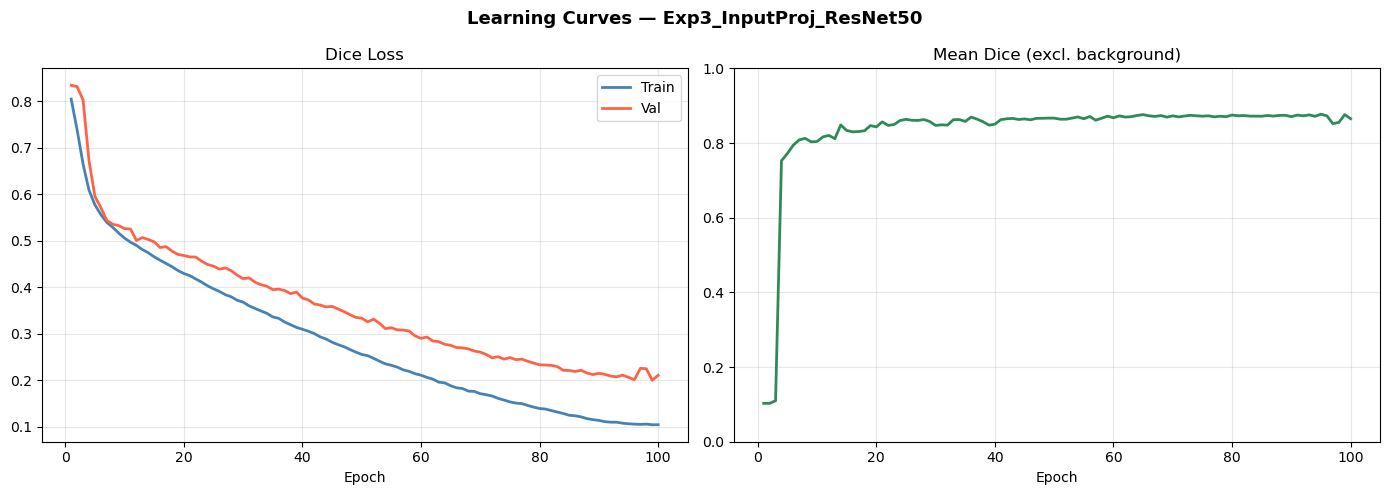

  Saved: seresunet_results/exp3\Exp3_InputProj_ResNet50_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp3_InputProj_ResNet50
───────────────────────────────────────────────────────
  Class                  Dice      IoU
  ------------------------------------
  background           0.8765   0.7804
  femoral_condyle      0.8942   0.8087
  lateral_js           0.8557   0.7489
  medial_js            0.8480   0.7372 ← key
  tibial_plateau       0.9292   0.8678
  ------------------------------------
  Mean (no bg)         0.8817   0.7907
  Pixel Accuracy       0.8942

  Progression so far:


NameError: name 'results_e1' is not defined

In [8]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 3 — INPUT PROJECTION ★1 + ResNet50 ENCODER ★2
#  Adds: Learned 1→3ch projection before encoder
#        Upgrades encoder to ResNet50
#  Same: plain double conv decoder, no SE, no aux
#  Purpose: Does learned projection + stronger encoder improve?
# ══════════════════════════════════════════════════════════════

EXP3_NAME = "Exp3_InputProj_ResNet50"
EXP3_DIR  = "seresunet_results/exp3"

print("\n" + "="*65)
print(f"  {EXP3_NAME}")
print("  Adds: ★1 Learned input projection (1→3ch)")
print("        ★2 ResNet50 pretrained (stronger encoder)")
print("  Same: plain conv decoder, no SE, no aux")
print("="*65)

model_e3 = InputProjUNet(num_classes=5).to(DEVICE)
opt_e3   = optim.Adam(model_e3.parameters(), lr=LR)
sch_e3   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_e3, mode='min', patience=5, factor=0.5)

history_e3 = run_training(
    model_e3, train_loader, val_loader,
    opt_e3, sch_e3,
    save_path=f"{EXP3_DIR}/{EXP3_NAME}_best.pth",
    exp_name=EXP3_NAME)

model_e3.load_state_dict(
    torch.load(f"{EXP3_DIR}/{EXP3_NAME}_best.pth",
               map_location=DEVICE))
plot_learning_curves(history_e3, EXP3_NAME, EXP3_DIR)
results_e3 = full_evaluate(
    model_e3, test_loader, EXP3_NAME, EXP3_DIR)
ALL_HISTORIES[EXP3_NAME] = history_e3

print(f"\n  Progression so far:")
print(f"  Exp1 Baseline       : "
      f"{results_e1['mean_dice_no_bg']:.4f}")
print(f"  Exp2 Pretrained     : "
      f"{results_e2['mean_dice_no_bg']:.4f}")
print(f"  Exp3 Proj+ResNet50  : "
      f"{results_e3['mean_dice_no_bg']:.4f}")


  Exp4_ResidualDecoder
  Adds: ★3 Residual double conv in decoder
  Same: ★1 input proj, ★2 ResNet50, no SE, no aux

  Exp4_ResidualDecoder
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------
     1 |   0.7770 |   0.8428 |    0.0141 |  0.0383
     2 |   0.6389 |   0.8297 |    0.1375 |  0.0283
     3 |   0.5441 |   0.7237 |    0.3887 |  0.2119
     4 |   0.4837 |   0.5574 |    0.5723 |  0.5188
     5 |   0.4416 |   0.5005 |    0.5672 |  0.4931
     6 |   0.4063 |   0.4461 |    0.6365 |  0.5494
     7 |   0.3707 |   0.4258 |    0.8187 |  0.7364
     8 |   0.3274 |   0.3757 |    0.8374 |  0.7641
     9 |   0.2965 |   0.3583 |    0.8333 |  0.7824
    10 |   0.2767 |   0.3330 |    0.8354 |  0.7674
    11 |   0.2567 |   0.3138 |    0.8557 |  0.8041
    12 |   0.2377 |   0.2858 |    0.8525 |  0.7916
    13 |   0.2281 |   0.2933 |    0.8560 |  0.7980
    14 |   0.2168 |   0.2723 |    0.8657 |  0.8197
    15 |   0.2049 |   0.2681 |    0.

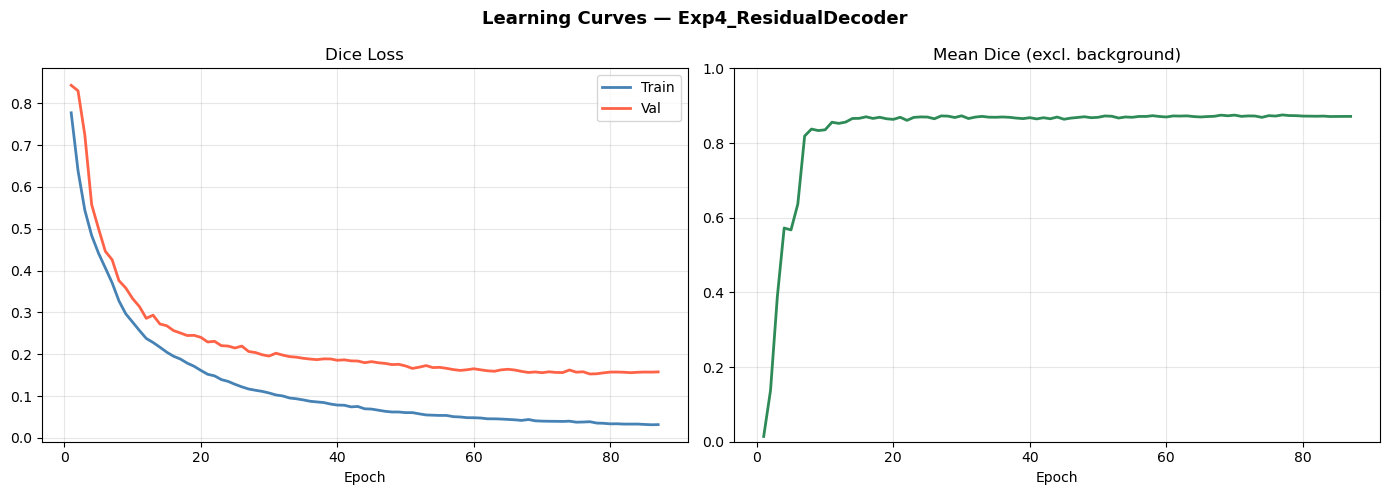

  Saved: seresunet_results/exp4\Exp4_ResidualDecoder_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp4_ResidualDecoder
───────────────────────────────────────────────────────
  Class                  Dice      IoU
  ------------------------------------
  background           0.8971   0.8137
  femoral_condyle      0.9051   0.8269
  lateral_js           0.8487   0.7383
  medial_js            0.8445   0.7314 ← key
  tibial_plateau       0.9370   0.8819
  ------------------------------------
  Mean (no bg)         0.8838   0.7947
  Pixel Accuracy       0.9074

  Medial JS progression (most important class):
  Exp3 Proj+ResNet50  : 0.8480
  Exp4 ResidualDec    : 0.8445


In [9]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 4 — RESIDUAL DECODER ★3
#  Adds: ResidualDoubleConv in all decoder blocks
#  Same: ★1 input proj, ★2 ResNet50, no SE, no aux
#  Purpose: Do residual shortcuts improve gradient flow
#           and medial_js segmentation on small dataset?
# ══════════════════════════════════════════════════════════════

EXP4_NAME = "Exp4_ResidualDecoder"
EXP4_DIR  = "seresunet_results/exp4"

print("\n" + "="*65)
print(f"  {EXP4_NAME}")
print("  Adds: ★3 Residual double conv in decoder")
print("  Same: ★1 input proj, ★2 ResNet50, no SE, no aux")
print("="*65)

model_e4 = ResDecUNet(num_classes=5).to(DEVICE)
opt_e4   = optim.Adam(model_e4.parameters(), lr=LR)
sch_e4   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_e4, mode='min', patience=5, factor=0.5)

history_e4 = run_training(
    model_e4, train_loader, val_loader,
    opt_e4, sch_e4,
    save_path=f"{EXP4_DIR}/{EXP4_NAME}_best.pth",
    exp_name=EXP4_NAME)

model_e4.load_state_dict(
    torch.load(f"{EXP4_DIR}/{EXP4_NAME}_best.pth",
               map_location=DEVICE))
plot_learning_curves(history_e4, EXP4_NAME, EXP4_DIR)
results_e4 = full_evaluate(
    model_e4, test_loader, EXP4_NAME, EXP4_DIR)
ALL_HISTORIES[EXP4_NAME] = history_e4

print(f"\n  Medial JS progression (most important class):")
# print(f"  Exp1 Baseline       : {results_e1['dice'][3]:.4f}")
# print(f"  Exp2 Pretrained     : {results_e2['dice'][3]:.4f}")
print(f"  Exp3 Proj+ResNet50  : {results_e3['dice'][3]:.4f}")
print(f"  Exp4 ResidualDec    : {results_e4['dice'][3]:.4f}")


  Exp5_SEResUNet_Proposed — PROPOSED ARCHITECTURE
  Adds: ★4 SE channel attention in decoder
        ★5 Deep supervision auxiliary head
  All : ★1 ★2 ★3 included

  Exp5_SEResUNet_Proposed
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------
     1 |   1.1219 |   1.1730 |    0.1028 |  0.0003
     2 |   1.0044 |   1.1514 |    0.1125 |  0.0003
     3 |   0.9189 |   1.0470 |    0.3607 |  0.0139
     4 |   0.8573 |   0.9075 |    0.4878 |  0.3179
     5 |   0.8117 |   0.8336 |    0.5871 |  0.5204
     6 |   0.7709 |   0.7966 |    0.7204 |  0.5579
     7 |   0.7350 |   0.7570 |    0.7741 |  0.5818
     8 |   0.6984 |   0.7225 |    0.7813 |  0.6135
     9 |   0.6695 |   0.6866 |    0.8188 |  0.7195
    10 |   0.6463 |   0.6704 |    0.8107 |  0.7171
    11 |   0.6257 |   0.6443 |    0.8297 |  0.7539
    12 |   0.6076 |   0.6479 |    0.8342 |  0.7681
    13 |   0.5878 |   0.6339 |    0.8239 |  0.7031
    14 |   0.5727 |   0.6176 |    0.83

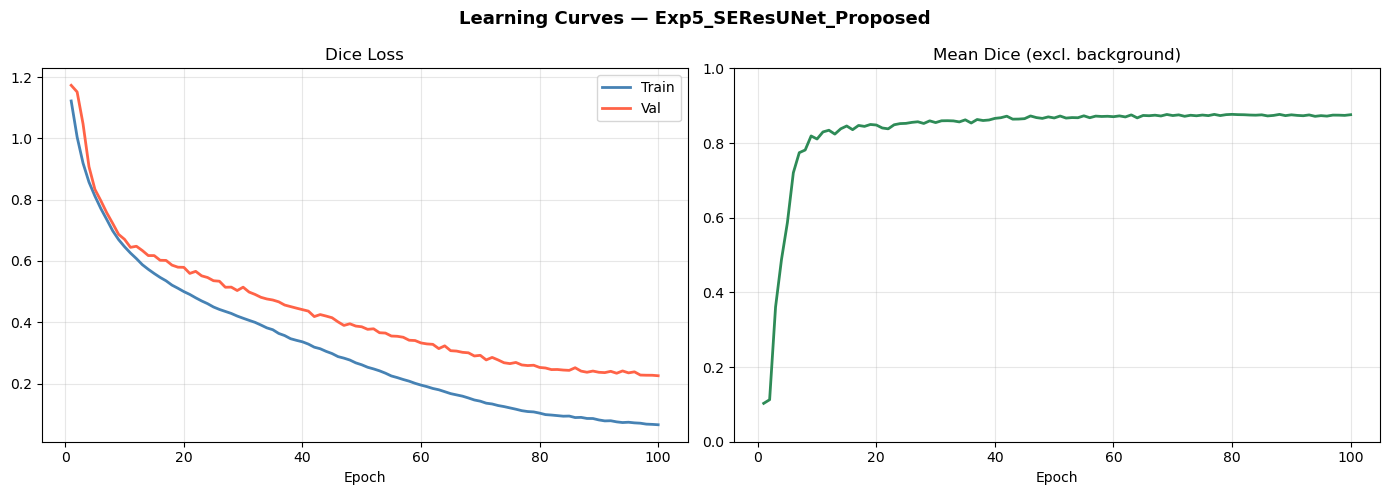

  Saved: seresunet_results/exp5\Exp5_SEResUNet_Proposed_curves.png

───────────────────────────────────────────────────────
  RESULTS: Exp5_SEResUNet_Proposed
───────────────────────────────────────────────────────
  Class                  Dice      IoU
  ------------------------------------
  background           0.9034   0.8242
  femoral_condyle      0.9182   0.8490
  lateral_js           0.8542   0.7461
  medial_js            0.8518   0.7427 ← key
  tibial_plateau       0.9415   0.8895
  ------------------------------------
  Mean (no bg)         0.8914   0.8068
  Pixel Accuracy       0.9155


In [10]:
# ══════════════════════════════════════════════════════════════
#  EXPERIMENT 5 — FULL SE-ResUNet (PROPOSED MODEL)
#  Adds: ★4 SE channel attention after each decoder block
#        ★5 Deep supervision auxiliary head at dec2
#  All : ★1 ★2 ★3 already included
#  Purpose: Final proposed architecture — does SE + deep sup
#           further improve medial_js segmentation?
# ══════════════════════════════════════════════════════════════

EXP5_NAME = "Exp5_SEResUNet_Proposed"
EXP5_DIR  = "seresunet_results/exp5"

print("\n" + "="*65)
print(f"  {EXP5_NAME} — PROPOSED ARCHITECTURE")
print("  Adds: ★4 SE channel attention in decoder")
print("        ★5 Deep supervision auxiliary head")
print("  All : ★1 ★2 ★3 included")
print("="*65)

model_e5 = SEResUNet(num_classes=5).to(DEVICE)
opt_e5   = optim.Adam(model_e5.parameters(), lr=LR)
sch_e5   = optim.lr_scheduler.ReduceLROnPlateau(
    opt_e5, mode='min', patience=5, factor=0.5)

history_e5 = run_training(
    model_e5, train_loader, val_loader,
    opt_e5, sch_e5,
    save_path=f"{EXP5_DIR}/{EXP5_NAME}_best.pth",
    exp_name=EXP5_NAME)

model_e5.load_state_dict(
    torch.load(f"{EXP5_DIR}/{EXP5_NAME}_best.pth",
               map_location=DEVICE))
plot_learning_curves(history_e5, EXP5_NAME, EXP5_DIR)
results_e5 = full_evaluate(
    model_e5, test_loader, EXP5_NAME, EXP5_DIR)
ALL_HISTORIES[EXP5_NAME] = history_e5

In [9]:
# ══════════════════════════════════════════════════════════════
#  FULL EXPERIMENT COMPARISON
# ══════════════════════════════════════════════════════════════

# print("\n" + "═"*70)
# print("  SE-ResUNet — FULL EXPERIMENTAL PROGRESSION")
# print("═"*70)
# print(f"  {'Experiment':<32} {'MeanDice':>10} "
#       f"{'MedJS':>8}  Contribution Added")
# print(f"  {'-'*65}")

# progression = [
#     (EXP1_NAME, results_e1, "Baseline — no contributions"),
#     (EXP2_NAME, results_e2, "★2 Pretrained encoder"),
#     (EXP3_NAME, results_e3, "★1 Input proj + ResNet50"),
#     (EXP4_NAME, results_e4, "★3 Residual decoder conv"),
#     (EXP5_NAME, results_e5, "★4 SE attention + ★5 Deep sup"),
# ]

# for name, res, note in progression:
#     marker = "→ " if "SEResUNet" in name else "  "
#     print(f"  {marker}{name:<30} "
#           f"{res['mean_dice_no_bg']:>10.4f} "
#           f"{res['dice'][3]:>8.4f}  {note}")

# plot_comparison("mean_dice_no_bg", "seresunet_results/final")

# # ── Overlay learning curves — medial JS progression ────────────
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.set_title(
#     "SE-ResUNet Contribution Progression\n"
#     "Medial Joint Space Dice per Epoch",
#     fontsize=12, fontweight="bold")

# colors_prog = {
#     EXP1_NAME: "#AAAAAA",
#     EXP2_NAME: "#9FE1CB",
#     EXP3_NAME: "#7F77DD",
#     EXP4_NAME: "#378ADD",
#     EXP5_NAME: "#D85A30",
# }
# labels_prog = {
#     EXP1_NAME: "Exp1 Baseline",
#     EXP2_NAME: "Exp2 + Pretrained",
#     EXP3_NAME: "Exp3 + InputProj + ResNet50",
#     EXP4_NAME: "Exp4 + ResidualDec",
#     EXP5_NAME: "Exp5 SE-ResUNet (proposed)",
# }

# for name, hist in ALL_HISTORIES.items():
#     if name not in colors_prog: continue
#     medial_curve = [d[3] for d in hist["dice_per_cls"]]
#     ax.plot(range(1, len(medial_curve)+1),
#             medial_curve,
#             label=labels_prog[name],
#             color=colors_prog[name],
#             linewidth=2.5 if "SEResUNet" in name else 1.5,
#             linestyle="-" if "SEResUNet" in name else "--")

# ax.set_xlabel("Epoch")
# ax.set_ylabel("Medial JS Dice")
# ax.set_ylim(0, 1.0)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(
#     "seresunet_results/final/medialjs_progression.png",
#     dpi=150, bbox_inches="tight")
# plt.show()

# ══════════════════════════════════════════════════════════════
#  HYPERPARAMETER OPTIMIZATION — on confirmed SE-ResUNet
# ══════════════════════════════════════════════════════════════

print("\n" + "="*65)
print("  HYPERPARAMETER OPTIMIZATION — SE-ResUNet")
print("  27 combinations: lr × batch_size × weight_decay")
print("="*65)

os.makedirs("seresunet_results/hp", exist_ok=True)

param_grid = {
    "lr":           [1e-3, 1e-4, 1e-5],
    "batch_size":   [4, 8, 16],
    "weight_decay": [0.0, 1e-4, 1e-3]
}

all_combinations = list(itertools.product(
    param_grid["lr"],
    param_grid["batch_size"],
    param_grid["weight_decay"]
))
print(f"  Total : {len(all_combinations)} combinations")

best_dice   = 0.0
best_params = {}
hp_summary  = []

for idx, (lr, bs, wd) in enumerate(all_combinations):
    run_name = f"lr{lr}_bs{bs}_wd{wd}"
    print(f"\n[{idx+1:2d}/27] {run_name}")

    t_loader, v_loader, te_loader = get_loaders(
        train_transform=transform_augmented, batch_size=bs)

    model_hp = SEResUNet(num_classes=5).to(DEVICE)
    opt_hp   = optim.Adam(
        model_hp.parameters(), lr=lr, weight_decay=wd)
    sch_hp   = optim.lr_scheduler.ReduceLROnPlateau(
        opt_hp, mode='min', patience=5, factor=0.5)

    history_hp = run_training(
        model_hp, t_loader, v_loader, opt_hp, sch_hp,
        save_path=f"seresunet_results/hp/{run_name}_best.pth",
        exp_name=run_name, epochs=30)

    model_hp.load_state_dict(torch.load(
        f"seresunet_results/hp/{run_name}_best.pth",
        map_location=DEVICE))
    model_hp.eval()

    dice_total = torch.zeros(NUM_CLASSES)
    with torch.no_grad():
        for images, masks in v_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            main_pred, _  = model_hp(images)
            dice_total   += torch.tensor(
                dice_per_class(main_pred, masks))

    dice_avg   = dice_total / len(v_loader)
    mean_dice  = dice_avg[1:].mean().item()
    medial_js  = dice_avg[3].item()

    print(f"  Mean Dice : {mean_dice:.4f} | "
          f"Medial JS : {medial_js:.4f}", end="")

    hp_summary.append({
        "run": run_name, "lr": lr,
        "batch_size": bs, "weight_decay": wd,
        "mean_dice": mean_dice, "medial_js": medial_js
    })

    if mean_dice > best_dice:
        best_dice   = mean_dice
        best_params = {"lr": lr, "bs": bs, "wd": wd}
        torch.save(model_hp.state_dict(),
                   "seresunet_results/hp/BEST_HP.pth")
        print("  ★ New best!")
    else:
        print()

df_hp = pd.DataFrame(hp_summary)
df_hp.to_csv("seresunet_results/hp/hp_summary.csv", index=False)

print(f"\n  Best params : {best_params}")
print(f"  Best Dice   : {best_dice:.4f}")
print(f"\n  Top 5:")
print(df_hp.sort_values("mean_dice", ascending=False)
          .head(5).to_string(index=False))

# ── HP Sensitivity Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "SE-ResUNet — Hyperparameter Sensitivity",
    fontsize=12, fontweight="bold")
for ax, param in zip(axes,
    ["lr", "batch_size", "weight_decay"]):
    grouped = df_hp.groupby(param)["mean_dice"]\
                   .mean().reset_index()
    bars = ax.bar(grouped[param].astype(str),
                  grouped["mean_dice"],
                  color="steelblue", edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_title(param, fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean Dice")
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("seresunet_results/hp/hp_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()


  HYPERPARAMETER OPTIMIZATION — SE-ResUNet
  27 combinations: lr × batch_size × weight_decay
  Total : 27 combinations

[ 1/27] lr0.001_bs4_wd0.0

  lr0.001_bs4_wd0.0
    Ep |   TrLoss |   VlLoss |  MeanDice |   MedJS
  -------------------------------------------------------


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1 |   0.9022 |   0.7961 |    0.4651 |  0.0003
     2 |   0.6640 |   0.5997 |    0.5834 |  0.5248
     3 |   0.5713 |   0.5721 |    0.5926 |  0.5286
     4 |   0.5089 |   0.5205 |    0.6231 |  0.5911
     5 |   0.4695 |   0.4753 |    0.6511 |  0.5716
     6 |   0.4467 |   0.4689 |    0.6289 |  0.3695
     7 |   0.4347 |   0.4339 |    0.6841 |  0.4276
     8 |   0.4270 |   0.4612 |    0.6334 |  0.3650
     9 |   0.4231 |   0.4212 |    0.7060 |  0.5833
    10 |   0.4033 |   0.3864 |    0.7391 |  0.6106
    11 |   0.4118 |   0.3528 |    0.7575 |  0.6704
    12 |   0.4051 |   0.4403 |    0.6555 |  0.4415
    13 |   0.3978 |   0.4641 |    0.6242 |  0.4667
    14 |   0.3948 |   0.5012 |    0.5913 |  0.2886
    15 |   0.4076 |   0.4733 |    0.6143 |  0.4632
    16 |   0.3947 |   0.4756 |    0.6326 |  0.3606
    17 |   0.3911 |   0.4541 |    0.6283 |  0.4178
    18 |   0.3868 |   0.4592 |    0.6249 |  0.3722
    19 |   0.3865 |   0.4291 |    0.6557 |  0.4608
    20 |   0.3655 |   0.3775 | 

RuntimeError: [enforce fail at inline_container.cc:668] . unexpected pos 50169280 vs 50169176